In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
BASE = Path(r"C:\ML\dummy_data")
TRAIN_DIR = BASE / "train"
TEST_DIR = BASE / "test"

def read_jsonl(path):
  rows = []
  with open(path, "r", encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      if line:
        rows.append(json.loads(line))
  return rows

train_raw = read_jsonl(TRAIN_DIR / "train.jsonl")
test_raw = read_jsonl(TEST_DIR / "test.jsonl")

train_df = pd.json_normalize(train_raw)
test_df = pd.json_normalize(test_raw)

# Convert numeric total
if "fields.total" in train_df.columns:
  train_df["fields.total_num"] = pd.to_numeric(train_df["fields.total"], errors="coerce")
if "fields.total" in test_df.columns:
  test_df["fields.total_num"] = pd.to_numeric(test_df["fields.total"], errors="coerce")

train_df.shape, test_df.shape

((20, 8), (10, 6))

In [3]:
print("TRAIN columns:")
print(train_df.columns.tolist())

print("\nTEST columns:")
print(test_df.columns.tolist())

train_df.head(3)

TRAIN columns:
['id', 'image_path', 'fields.vendor', 'fields.date', 'fields.total', 'label.is_forged', 'label.fraud_type', 'fields.total_num']

TEST columns:
['id', 'image_path', 'fields.vendor', 'fields.date', 'fields.total', 'fields.total_num']


,id,image_path,fields.vendor,fields.date,fields.total,label.is_forged,label.fraud_type,fields.total_num
0,r001,images/r001.png,ACME Corp,2024-01-24,141.14,0,none,141.14
1,r002,images/r002.png,Gulf Mart,2024-12-04,339.97,1,price_change,339.97
2,r003,images/r003.png,Quick Shop,2024-02-19,213.85,0,none,213.85


In [4]:
key_cols = [c for c in [
  "fields.vendor", "fields.date", "fields.total", "label.is_forged", "label.fraud_type"
] if c in train_df.columns]

missing_rate = train_df[key_cols].isna().mean().sort_values(ascending=False)
missing_rate

fields.vendor       0.0
fields.date         0.0
fields.total        0.0
label.is_forged     0.0
label.fraud_type    0.0
dtype: float64

In [5]:
if "label.is_forged" in train_df.columns:
  train_df["label.is_forged"].value_counts(dropna=False)

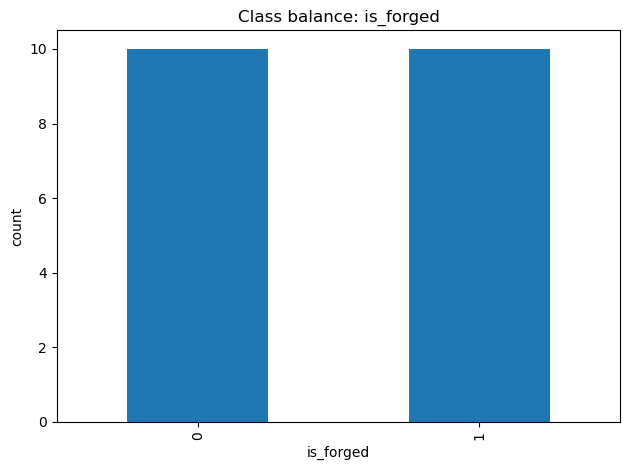

In [6]:
if "label.is_forged" in train_df.columns:
  plt.figure()
  train_df["label.is_forged"].value_counts().sort_index().plot(kind="bar")
  plt.title("Class balance: is_forged")
  plt.xlabel("is_forged")
  plt.ylabel("count")
  plt.tight_layout()
  plt.show()

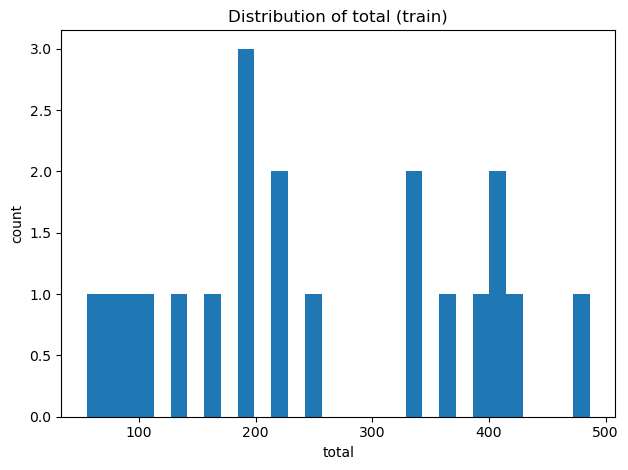

In [7]:
if "fields.total_num" in train_df.columns:
  plt.figure()
  train_df["fields.total_num"].dropna().plot(kind="hist", bins=30)
  plt.title("Distribution of total (train)")
  plt.xlabel("total")
  plt.ylabel("count")
  plt.tight_layout()
  plt.show()

  train_df["fields.total_num"].describe()

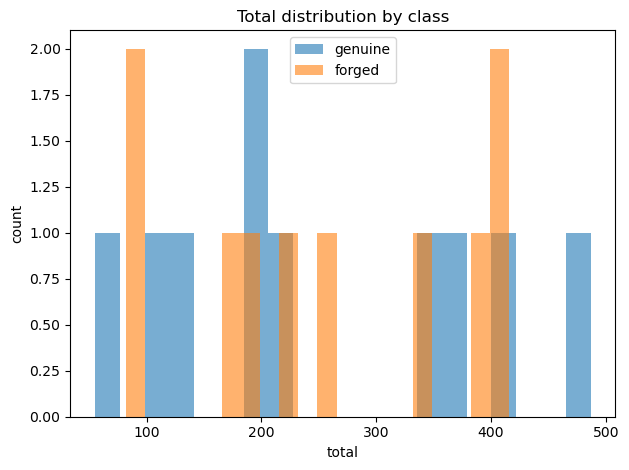

Genuine total describe:
 count     10.000000
mean     248.280000
std      141.149765
min       55.000000
25%      154.062500
50%      203.455000
75%      353.757500
max      486.690000
Name: fields.total_num, dtype: float64

Forged total describe:
 count     10.000000
mean     255.302000
std      126.408108
min       81.960000
25%      170.537500
50%      241.255000
75%      375.745000
max      415.560000
Name: fields.total_num, dtype: float64


In [8]:
if "fields.total_num" in train_df.columns and "label.is_forged" in train_df.columns:
  g0 = train_df.loc[train_df["label.is_forged"] == 0, "fields.total_num"].dropna()
  g1 = train_df.loc[train_df["label.is_forged"] == 1, "fields.total_num"].dropna()

  plt.figure()
  g0.plot(kind="hist", bins=20, alpha=0.6, label="genuine")
  g1.plot(kind="hist", bins=20, alpha=0.6, label="forged")
  plt.title("Total distribution by class")
  plt.xlabel("total")
  plt.ylabel("count")
  plt.legend()
  plt.tight_layout()
  plt.show()

  print("Genuine total describe:\n", g0.describe())
  print("\nForged total describe:\n", g1.describe())

In [9]:
if "fields.vendor" in train_df.columns:
  train_df["fields.vendor"].value_counts().head(15)

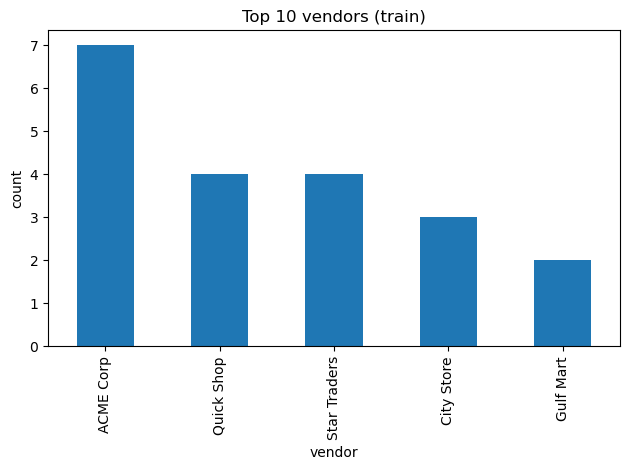

In [10]:
if "fields.vendor" in train_df.columns:
  plt.figure()
  train_df["fields.vendor"].value_counts().head(10).plot(kind="bar")
  plt.title("Top 10 vendors (train)")
  plt.xlabel("vendor")
  plt.ylabel("count")
  plt.tight_layout()
  plt.show()

In [11]:
if "fields.vendor" in train_df.columns and "fields.total_num" in train_df.columns:
  vendor_stats = (
    train_df.dropna(subset=["fields.vendor", "fields.total_num"])
      .groupby("fields.vendor")["fields.total_num"]
      .agg(["count", "mean", "std", "min", "max", "median"])
      .sort_values("count", ascending=False)
  )
  vendor_stats.head(10)

In [12]:
if "label.fraud_type" in train_df.columns:
  train_df["label.fraud_type"].value_counts(dropna=False)

In [13]:
def robust_zscore(x):
  x = np.asarray(x)
  med = np.nanmedian(x)
  mad = np.nanmedian(np.abs(x - med))
  if mad == 0:
    return np.zeros_like(x, dtype=float)
  return 0.6745 * (x - med) / mad

if "fields.total_num" in train_df.columns:
  rz = robust_zscore(train_df["fields.total_num"].values)
  train_df["total_robust_z"] = rz

  # Show most extreme totals
  train_df.sort_values("total_robust_z", ascending=False)[
    ["id", "fields.vendor", "fields.total", "fields.total_num", "label.is_forged", "label.fraud_type", "total_robust_z"]
  ].head(10)

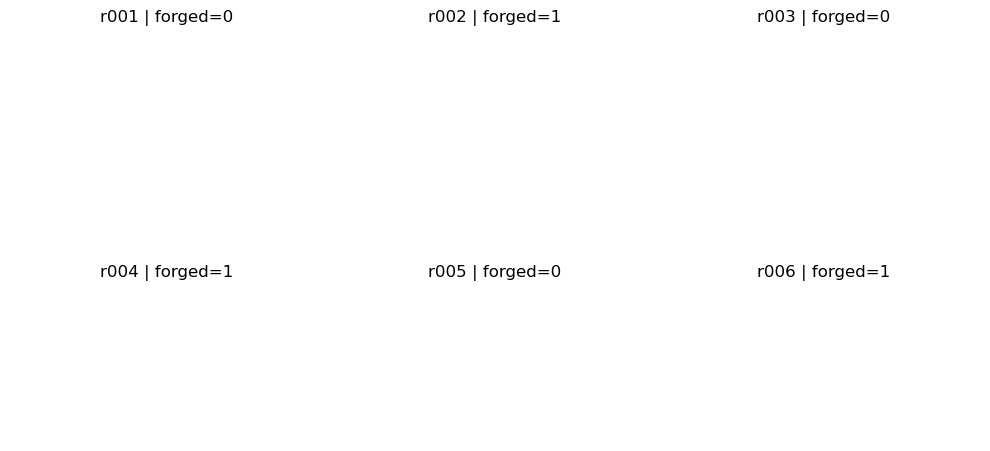

In [14]:
import matplotlib.image as mpimg

def show_samples(df, split_dir, n=6):
  plt.figure(figsize=(10, 6))
  for i in range(min(n, len(df))):
    row = df.iloc[i]
    img_path = split_dir / row["image_path"]
    img = mpimg.imread(img_path)

    title = str(row["id"])
    if "label.is_forged" in df.columns:
      title += f' | forged={row.get("label.is_forged", None)}'

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)
  plt.tight_layout()
  plt.show()

show_samples(train_df, TRAIN_DIR, n=6)